# [LAB 10] 2. 회귀모형 평가와 진단
## #01. 준비작업
### 1. 라이브러리 참조

In [27]:
from hossam import load_data
from helpers import *

import numpy as np
from pandas import DataFrame, concat
from IPython.display import Markdown

# 성능 평가 지표(직접 계산하지 않고 sklearn의 함수를 사용한다)
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

### 2. 체크포인트 데이터 로드
- 전처리 단계가 하나씩 누적된 5개의 데이터셋을 불러온다

In [28]:
df0 = load_data("boston_checkpoint_0")
df1 = load_data("boston_checkpoint_1")
df2 = load_data("boston_checkpoint_2")
df3 = load_data("boston_checkpoint_3")
df4 = load_data("boston_checkpoint_4")

📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 0 - 기준선 역할을 위해 라벨링과 더미변수 처리만 적용됨
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 1 - 라벨링 + 더미변수 + 로그변환
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 2 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 3 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체 + 다중공선성제거
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 4 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체 + 다중공선성제거 + 스케일링


### 3. 분석 대상 정리
- 5개 체크포인트를 딕셔너리로 묶고, 체크포인트별로 종속변수에 log1P가 적용되었는지 여부를 함께 기록한다.

In [29]:
# 종속변수
target = "MEDV"

# 비교 대상 체크포인트 (아래로 갈수록 전처리가 하나씩 누적된다)
checkpoints = { "0_기준선": df0, "1_로그변환": df1, "2_이상치대체": df2,
                "3_공선성제거": df3, "4_스케일링": df4 }

# 종속변수(MEDV)에 log1p 가 적용되었는지 여부 (체크포인트 1부터 적용됨)
log_y = { "0_기준선": False, "1_로그변환": True, "2_이상치대체": True,
          "3_공선성제거": True, "4_스케일링": True }

# 로그변환(log1p)이 적용된 독립변수 -> 최종 모델의 회귀계수 해석에 사용한다
log1p_x = ["CRIM", "ZN", "DIS", "RAD", "LSTAT"]

### 4. 종속 변수 척도 확인
- 체크포인트 1 이후부터 종속 변수의 척도가 다름을 확인

In [30]:
medv_scale = DataFrame()

for name in checkpoints:
    data = checkpoints[name]
    medv_scale[name] = data[target].describe()

medv_scale.round(3)

,0_기준선,1_로그변환,2_이상치대체,3_공선성제거,4_스케일링
count,506.000,506.000,506.000,506.000,506.000
mean,22.533,3.085,3.085,3.085,3.085
std,9.197,0.387,0.387,0.387,0.387
min,5.000,1.792,1.792,1.792,1.792
25%,17.025,2.892,2.892,2.892,2.892
50%,21.200,3.100,3.100,3.100,3.100
75%,25.000,3.258,3.258,3.258,3.258
max,50.000,3.932,3.932,3.932,3.932


## #02. 체크포인트별 모델 적합 및 성능비교
### 1. 체크포인트마다 모델을 적합(후진소거 포함)

In [31]:
fits = {}
result = []

for c in checkpoints:
    data = checkpoints[c]          # 체크포인트 데이터프레임
    log = log_y[c]                 # 종속변수에 log1p 가 적용되었는지 여부

    # --- 1) 모델 적합 (후진제거 포함) ---
    fit = my_ols.auto_ols(data, target,
                          log1p_y=log, log1p_x=log1p_x,
                          backward=True, report=False, test=False)

    fits[c] = fit

    # --- 2) 실제값과 예측값을 원본 척도(천 달러)로 되돌린다 ---
    if log:
        y_true = np.expm1(data[target])       # 종속변수 역변환
        y_pred = np.expm1(fit.fittedvalues)   # 예측값 역변환
    else:
        y_true = data[target]                 # 체크포인트 0 은 이미 원본 척도
        y_pred = fit.fittedvalues

    # --- 3) 지표를 한 행으로 정리해 저장 ---
    result.append({
        "모델": c,
        "변수수": int(fit.df_model),             # 상수항을 제외한 독립변수 개수
        "R2(모델척도)": fit.rsquared,            # 체크포인트간 비교 불가
        "Adj.R2": fit.rsquared_adj,              # 같은 종속변수끼리만 비교
        "AIC": fit.aic,                          # 같은 종속변수끼리만 비교
        "BIC": fit.bic,                          # 같은 종속변수끼리만 비교
        # 아래 세 지표는 원본 척도에서 계산하므로 체크포인트간 비교가 가능하다
        "R2(원본척도)": r2_score(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),  # 최종 선택 기준
        "MAE": mean_absolute_error(y_true, y_pred),
    })

rdf = DataFrame(result).set_index("모델")
rdf.round(4)


유의하지 않은 독립변수 제거 → AGE (p = 0.9678)
유의하지 않은 독립변수 제거 → INDUS (p = 0.6898)

유의하지 않은 독립변수 제거 → ZN (p = 0.9968)
유의하지 않은 독립변수 제거 → B (p = 0.7881)
유의하지 않은 독립변수 제거 → INDUS (p = 0.5519)
유의하지 않은 독립변수 제거 → AGE (p = 0.2722)

유의하지 않은 독립변수 제거 → ZN (p = 0.9069)
유의하지 않은 독립변수 제거 → B (p = 0.8131)
유의하지 않은 독립변수 제거 → INDUS (p = 0.5008)
유의하지 않은 독립변수 제거 → AGE (p = 0.3039)

유의하지 않은 독립변수 제거 → ZN (p = 0.9069)
유의하지 않은 독립변수 제거 → B (p = 0.8131)
유의하지 않은 독립변수 제거 → INDUS (p = 0.5008)
유의하지 않은 독립변수 제거 → AGE (p = 0.3039)

유의하지 않은 독립변수 제거 → ZN (p = 0.9069)
유의하지 않은 독립변수 제거 → B (p = 0.8131)
유의하지 않은 독립변수 제거 → INDUS (p = 0.5008)
유의하지 않은 독립변수 제거 → AGE (p = 0.3039)


,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE
모델,,,,,,,,
0_기준선,11,0.741,0.735,3021.726,3072.445,0.741,4.680,3.272
1_로그변환,9,0.792,0.789,-301.461,-259.196,0.789,4.215,2.973
2_이상치대체,9,0.791,0.787,-297.591,-255.326,0.787,4.237,2.982
3_공선성제거,9,0.791,0.787,-297.591,-255.326,0.787,4.237,2.982
4_스케일링,9,0.791,0.787,-297.591,-255.326,0.787,4.237,2.982


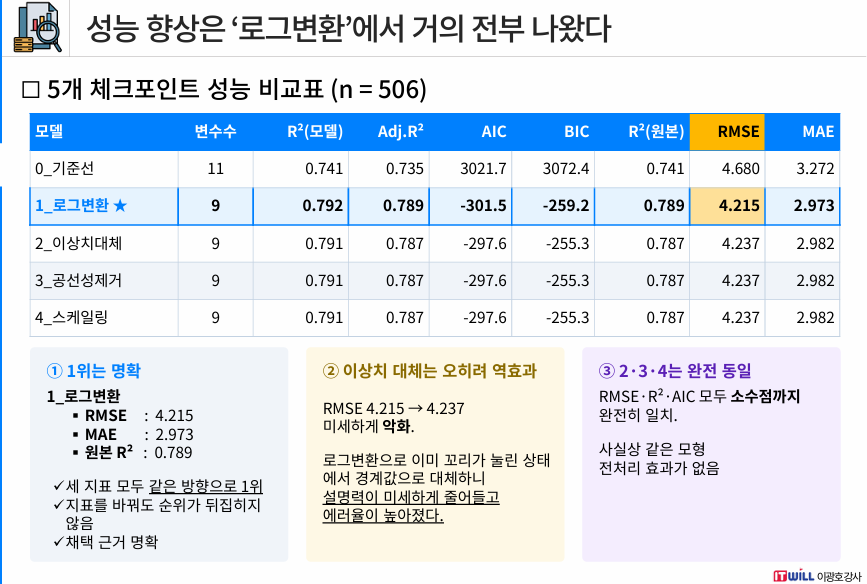

### 2. 최종 모델 채택 -> 1_로그변환
- 성능표를 슬라이드의 채택기준(1순위 원본척도 RMSE, 2순위 간명성)으로 읽으면 '1_로그변환'이 선택된다
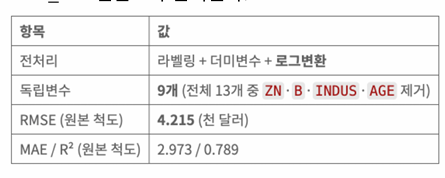
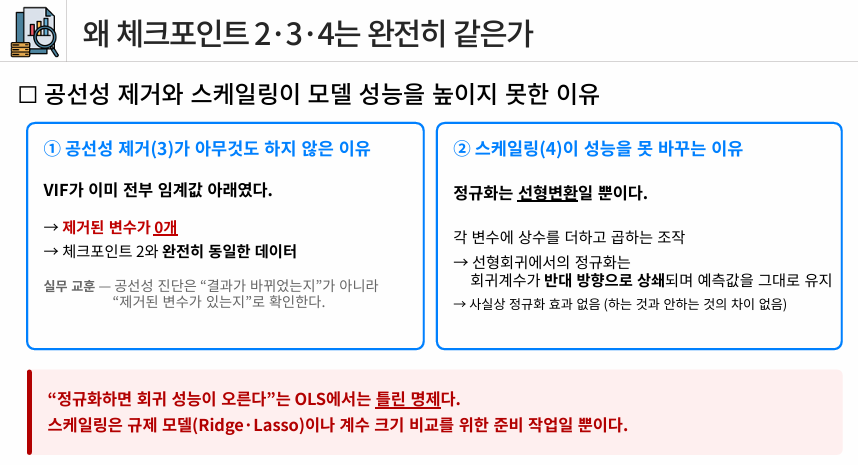
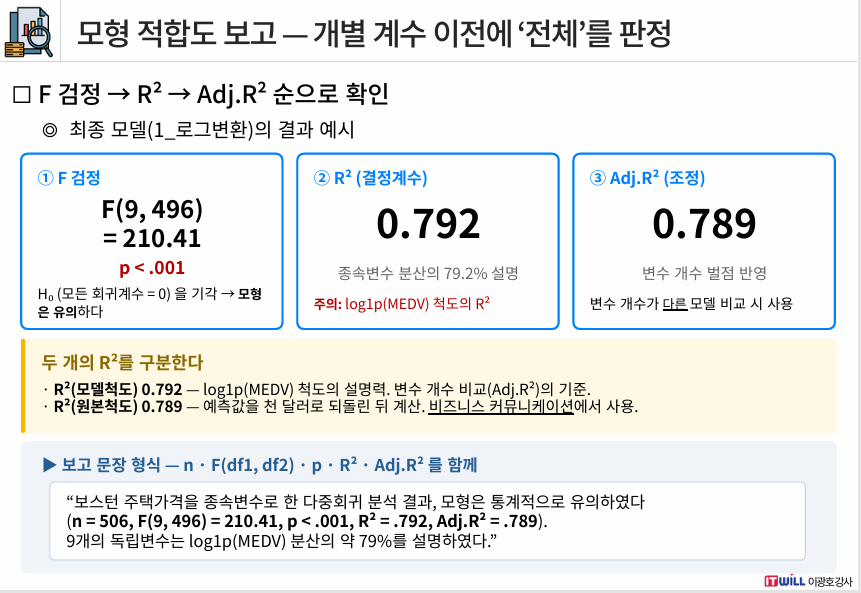

In [32]:
final_fit = fits['1_로그변환']
final_data = checkpoints["1_로그변환"]

## #03. 최종 모델 분석 결과 보고
### 1. 모형 적합도

In [33]:
display(Markdown(
    my_ols.report_fitness(final_fit, log1p_y=True,
                          log1p_x=log1p_x)
))

**Note. n = 506. F(9, 496) = 210.41, p < 0.001, R² = 0.792, Adj.R² = 0.789, Durbin_Watson = 1.037**

log1p(MEDV)를 종속변수로, log1p(CRIM), CHAS, NOX, RM, log1p(DIS), log1p(RAD), TAX, PTRATIO, log1p(LSTAT)(을)를 독립변수로 한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(9, 496) = 210.41 , p < 0.001, R² = 0.792.

즉, log1p(CRIM), CHAS, NOX, RM, log1p(DIS), log1p(RAD), TAX, PTRATIO, log1p(LSTAT)는 log1p(MEDV)의 약 79.24%를 설명하는 것으로 나타났다.

### 2. 회귀계수 보고

In [34]:
my_ols.report_variables(final_fit, final_data, hc3=True)

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,MEDV,LSTAT,-0.414,0.024,0.036,-0.576,-16.903,-11.433,0.000,0.000,0.360,2.777
1,MEDV,CRIM,-0.152,0.019,0.025,-0.401,-8.094,-6.083,0.000,0.000,0.171,5.857
2,MEDV,RAD,0.166,0.025,0.025,0.323,6.678,6.553,0.000,0.000,0.179,5.585
3,MEDV,DIS,-0.269,0.035,0.040,-0.288,-7.675,-6.799,0.000,0.000,0.298,3.353
4,MEDV,PTRATIO,-0.030,0.005,0.004,-0.170,-6.718,-7.687,0.000,0.000,0.653,1.532
5,MEDV,NOX,-0.556,0.141,0.159,-0.167,-3.954,-3.502,0.000,0.001,0.236,4.239
6,MEDV,TAX,-0.000,0.000,0.000,-0.138,-2.799,-2.270,0.005,0.024,0.173,5.774
7,MEDV,RM,0.066,0.016,0.024,0.119,4.230,2.753,0.000,0.006,0.526,1.900
8,MEDV,CHAS,0.095,0.032,0.038,0.063,2.969,2.533,0.003,0.012,0.944,1.060


### 3. 영향력 순위 시각화(표준화 계수 β)

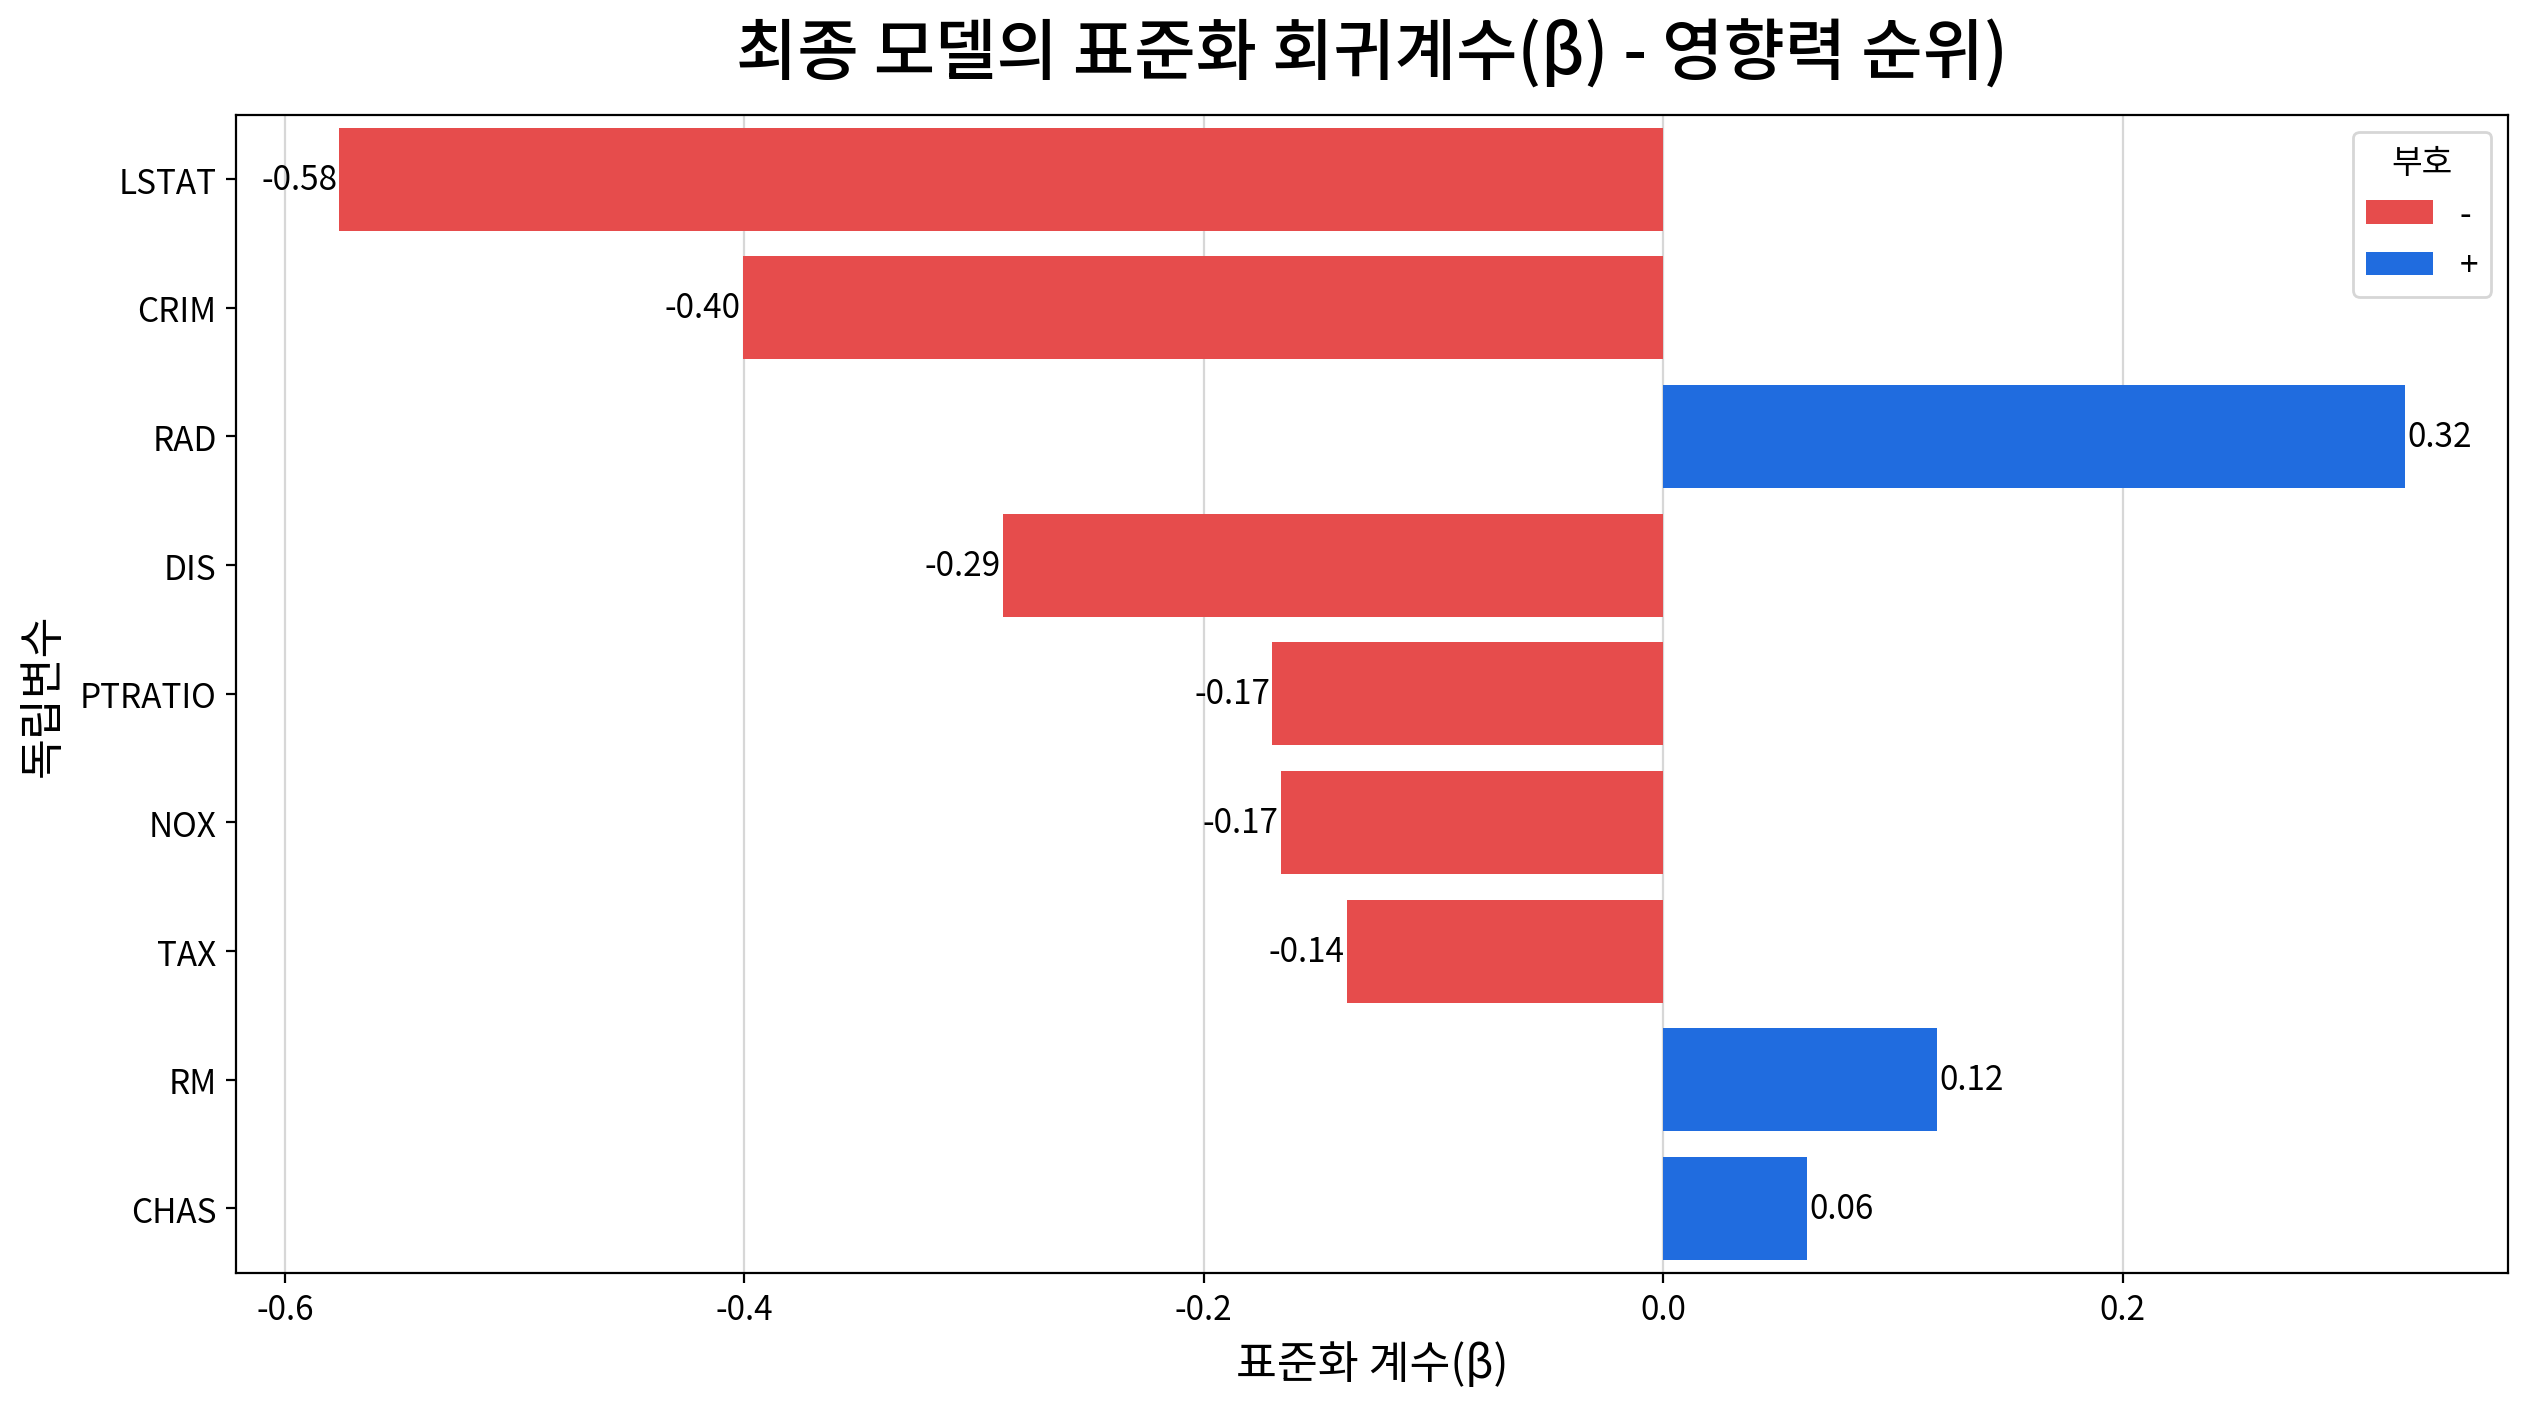

In [35]:
my_ols.plot_beta(final_fit, final_data, title="최종 모델의 표준화 회귀계수(β) - 영향력 순위)")

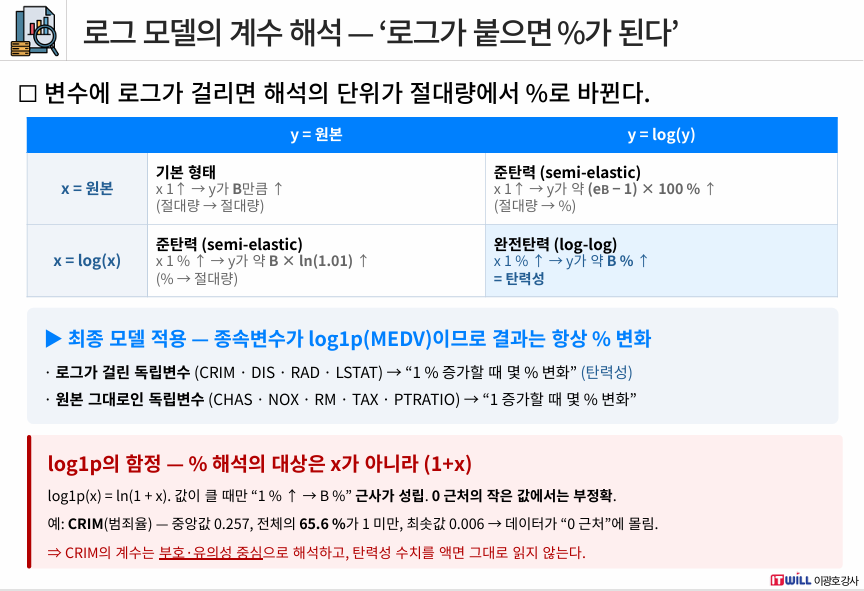

### 4. 회귀계수 해석 문장

In [36]:
display(Markdown(
    my_ols.report_variables_text(final_fit,
                                 log1p_y=True, log1p_x=log1p_x, hc3=True)
))

- **CRIM**의 회귀계수는 **B = -0.15**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(496) = -6.08**, **p < .001**) 즉, **(1+CRIM)가 1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.15% 감소**하는 것으로 해석된다.
- **CHAS**의 회귀계수는 **B = 0.1**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(496) = 2.53**, **p = .012**) 즉, **CHAS가 1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **9.99% 증가**하는 것으로 해석된다.
- **NOX**의 회귀계수는 **B = -0.56**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(496) = -3.5**, **p < .001**) 즉, **NOX가 1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **42.66% 감소**하는 것으로 해석된다.
- **RM**의 회귀계수는 **B = 0.07**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(496) = 2.75**, **p = .006**) 즉, **RM가 1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **6.79% 증가**하는 것으로 해석된다.
- **DIS**의 회귀계수는 **B = -0.27**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(496) = -6.8**, **p < .001**) 즉, **(1+DIS)가 1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.27% 감소**하는 것으로 해석된다.
- **RAD**의 회귀계수는 **B = 0.17**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(496) = 6.55**, **p < .001**) 즉, **(1+RAD)가 1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.17% 증가**하는 것으로 해석된다.
- **TAX**의 회귀계수는 **B = -0.0**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(496) = -2.27**, **p = .024**) 즉, **TAX가 1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.03% 감소**하는 것으로 해석된다.
- **PTRATIO**의 회귀계수는 **B = -0.03**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(496) = -7.69**, **p < .001**) 즉, **PTRATIO가 1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **2.99% 감소**하는 것으로 해석된다.
- **LSTAT**의 회귀계수는 **B = -0.41**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(496) = -11.43**, **p < .001**) 즉, **(1+LSTAT)가 1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.41% 감소**하는 것으로 해석된다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다. 회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며, 표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

> ※ **log1p**(=ln(1+.))의 % 해석은 변수 자체가 아니라 **(1+변수)** 기준이며, 값이 클 때만 위 근사가 성립한다(0·작은 값 구간에서는 원본처럼 동작해 부정확). 이 구간에서는 부호·유의성 중심으로 해석하거나 예측값을 expm1로 원 척도에서 비교한다.

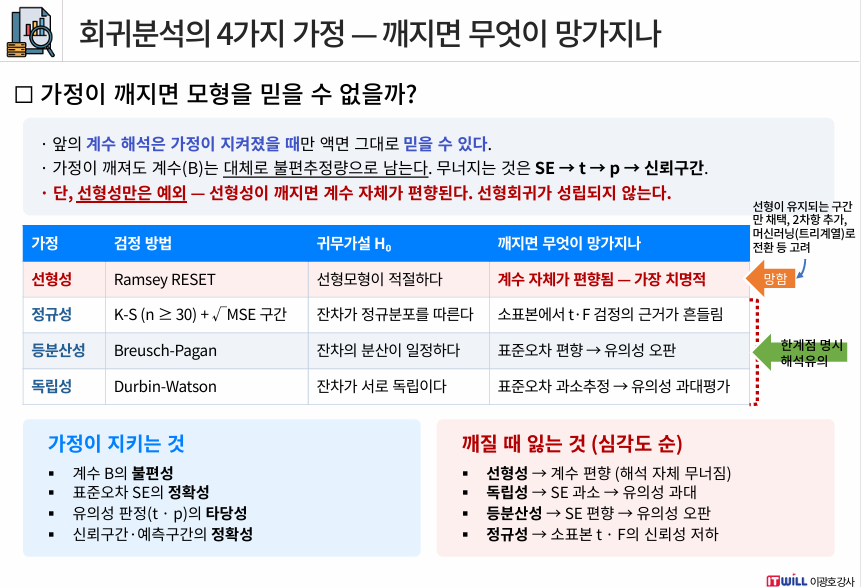

## #04. 최종 모델의 회귀분석 가정 검정
### 1. 선형성 검정

,statistic,p-value,linearity,result
Ramsey RESET,5.635,0.018,False,대립가설 채택 → 선형성 위배(곡선 관계 존재)


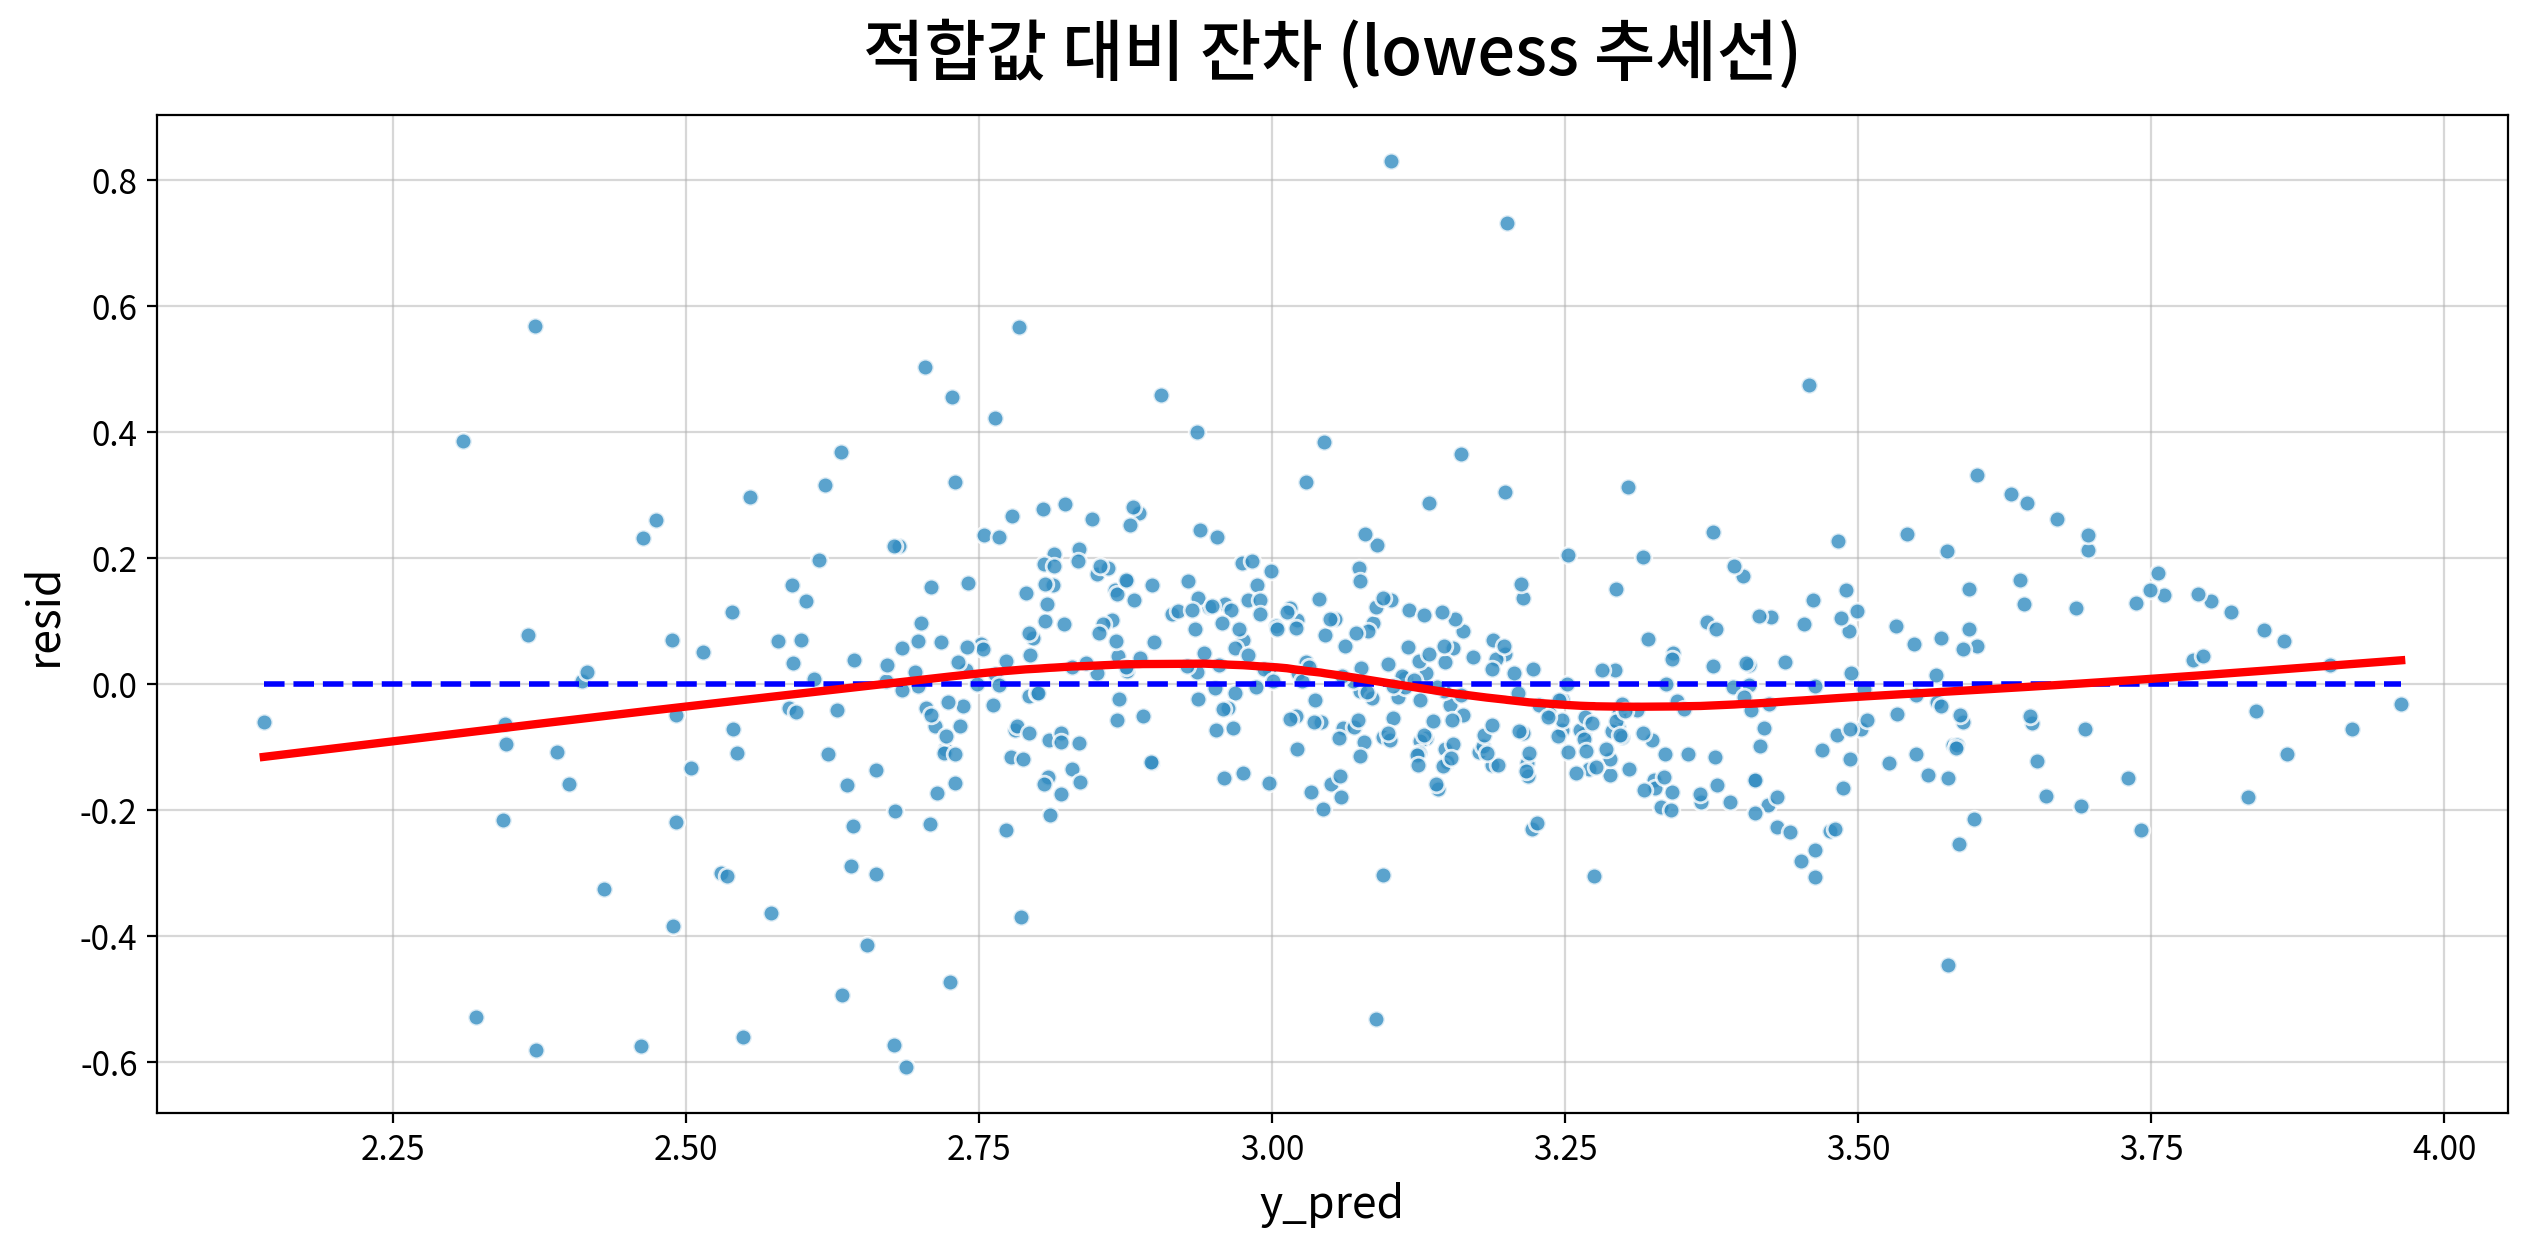

In [37]:
my_ols.test_linear(final_fit, plot=True,
                   title="적합값 대비 잔차 (lowess 추세선)")

### 2. 정규성 검정

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.060,0.049,False,대립가설 채택 → 정규성 위배


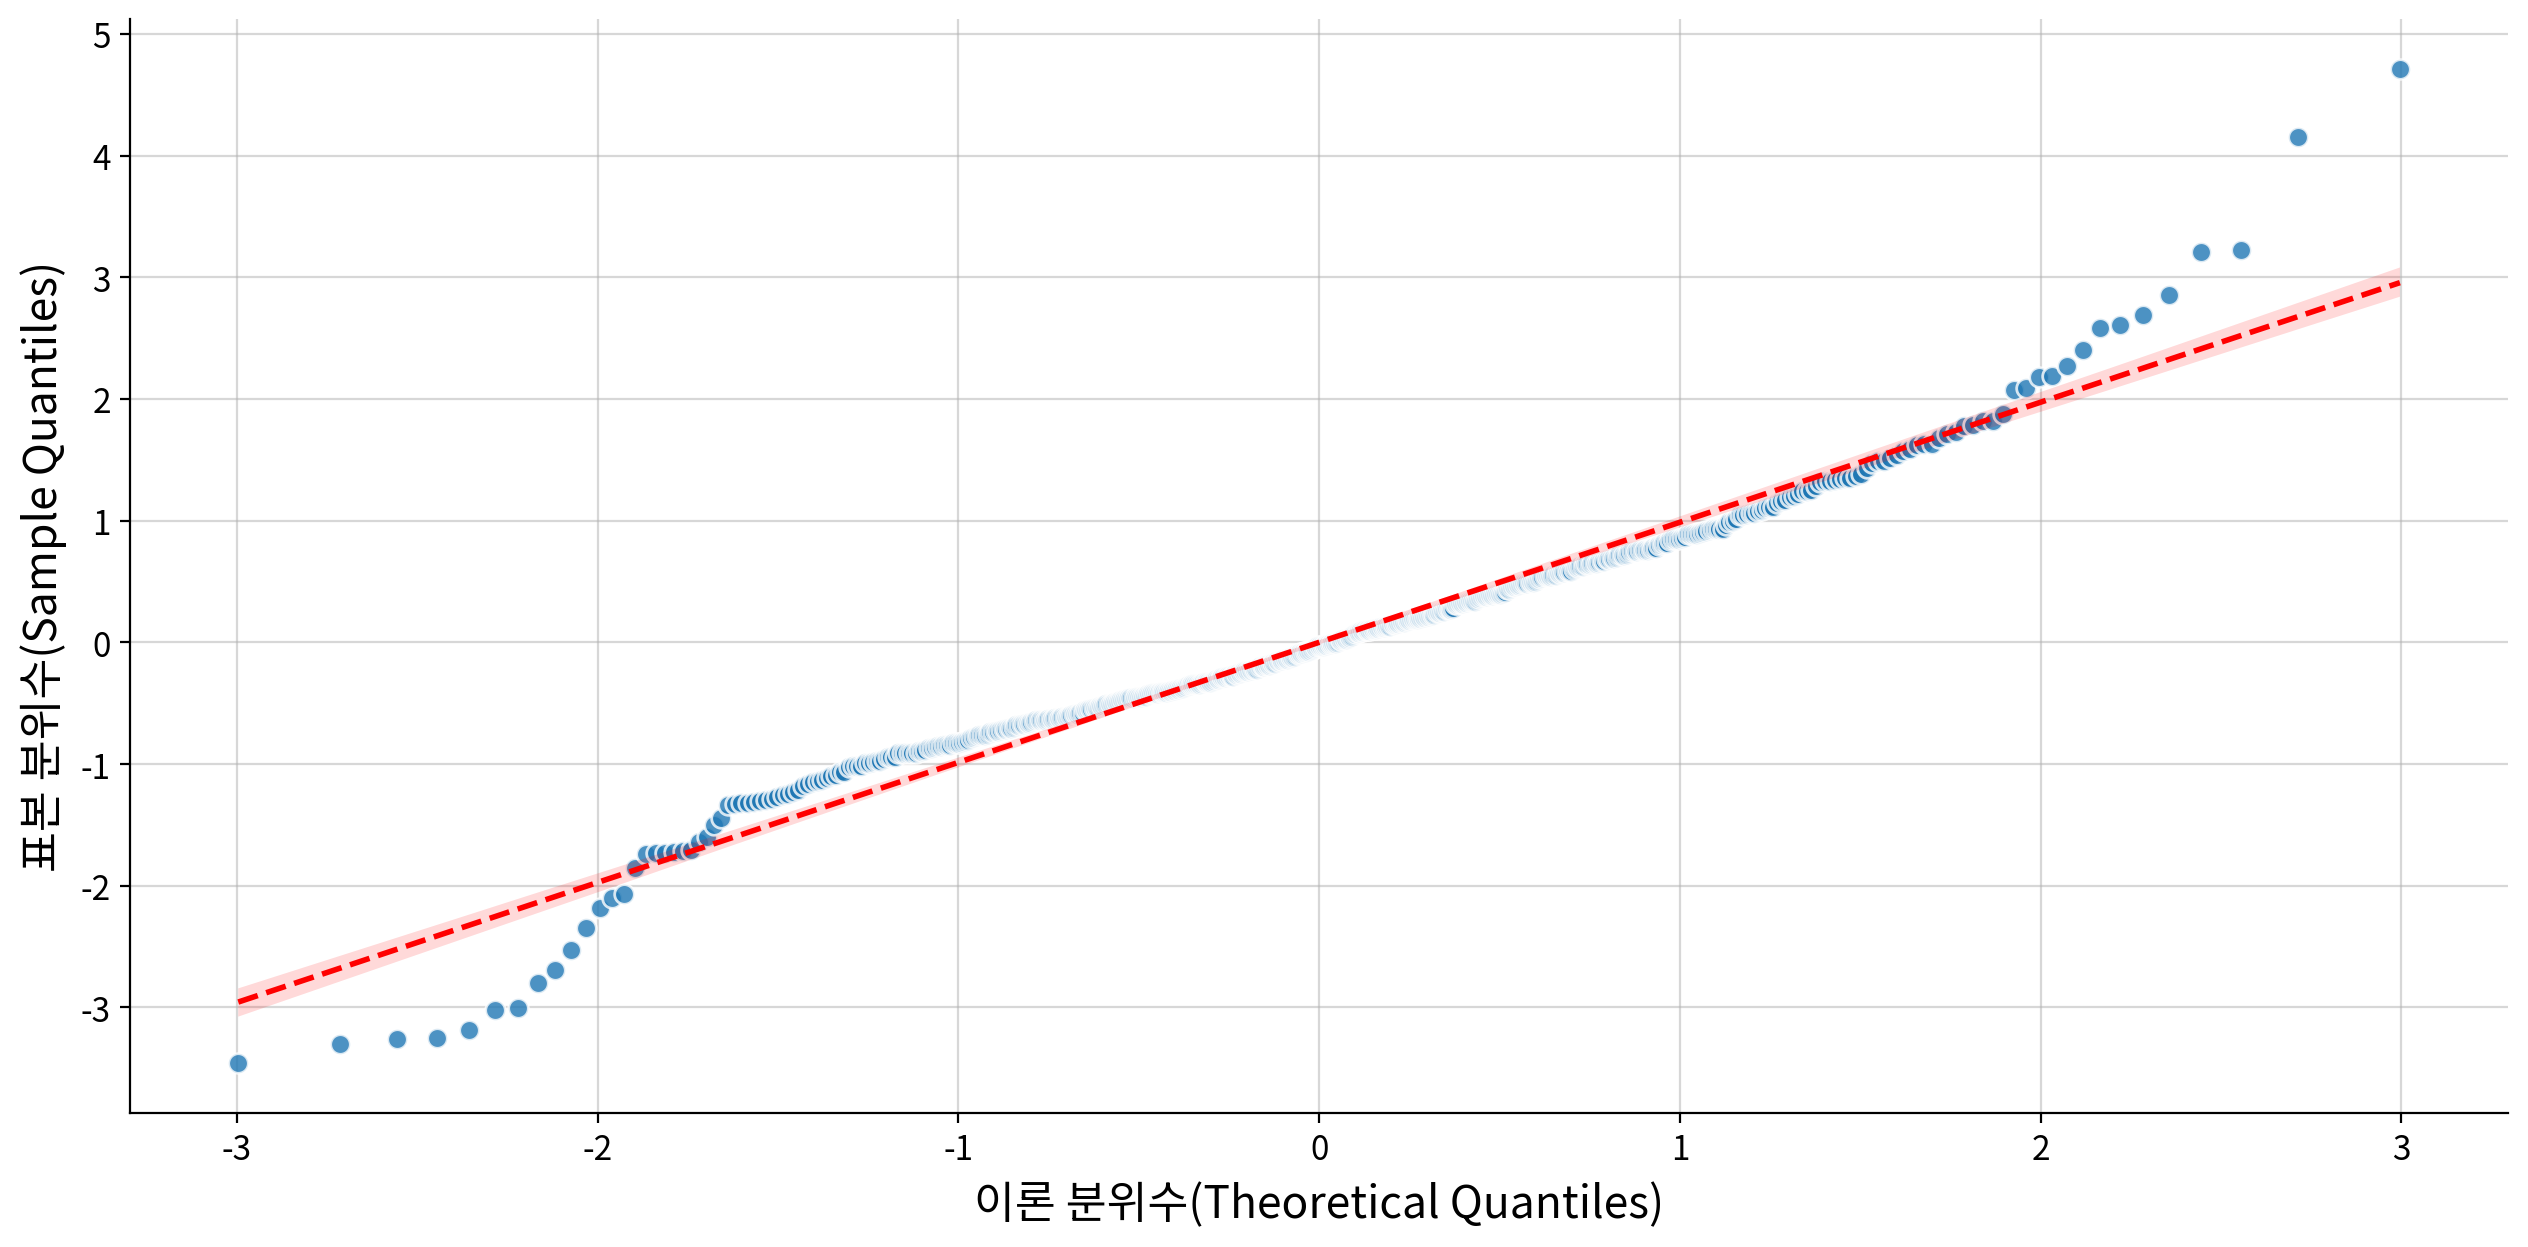

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,64~72,77.270,위배
±2√MSE,95.000,93~97,94.470,충족
±3√MSE,99.700,99~100,98.220,위배


√MSE = 0.18 / 구간 규칙 판정: 정규성 위배


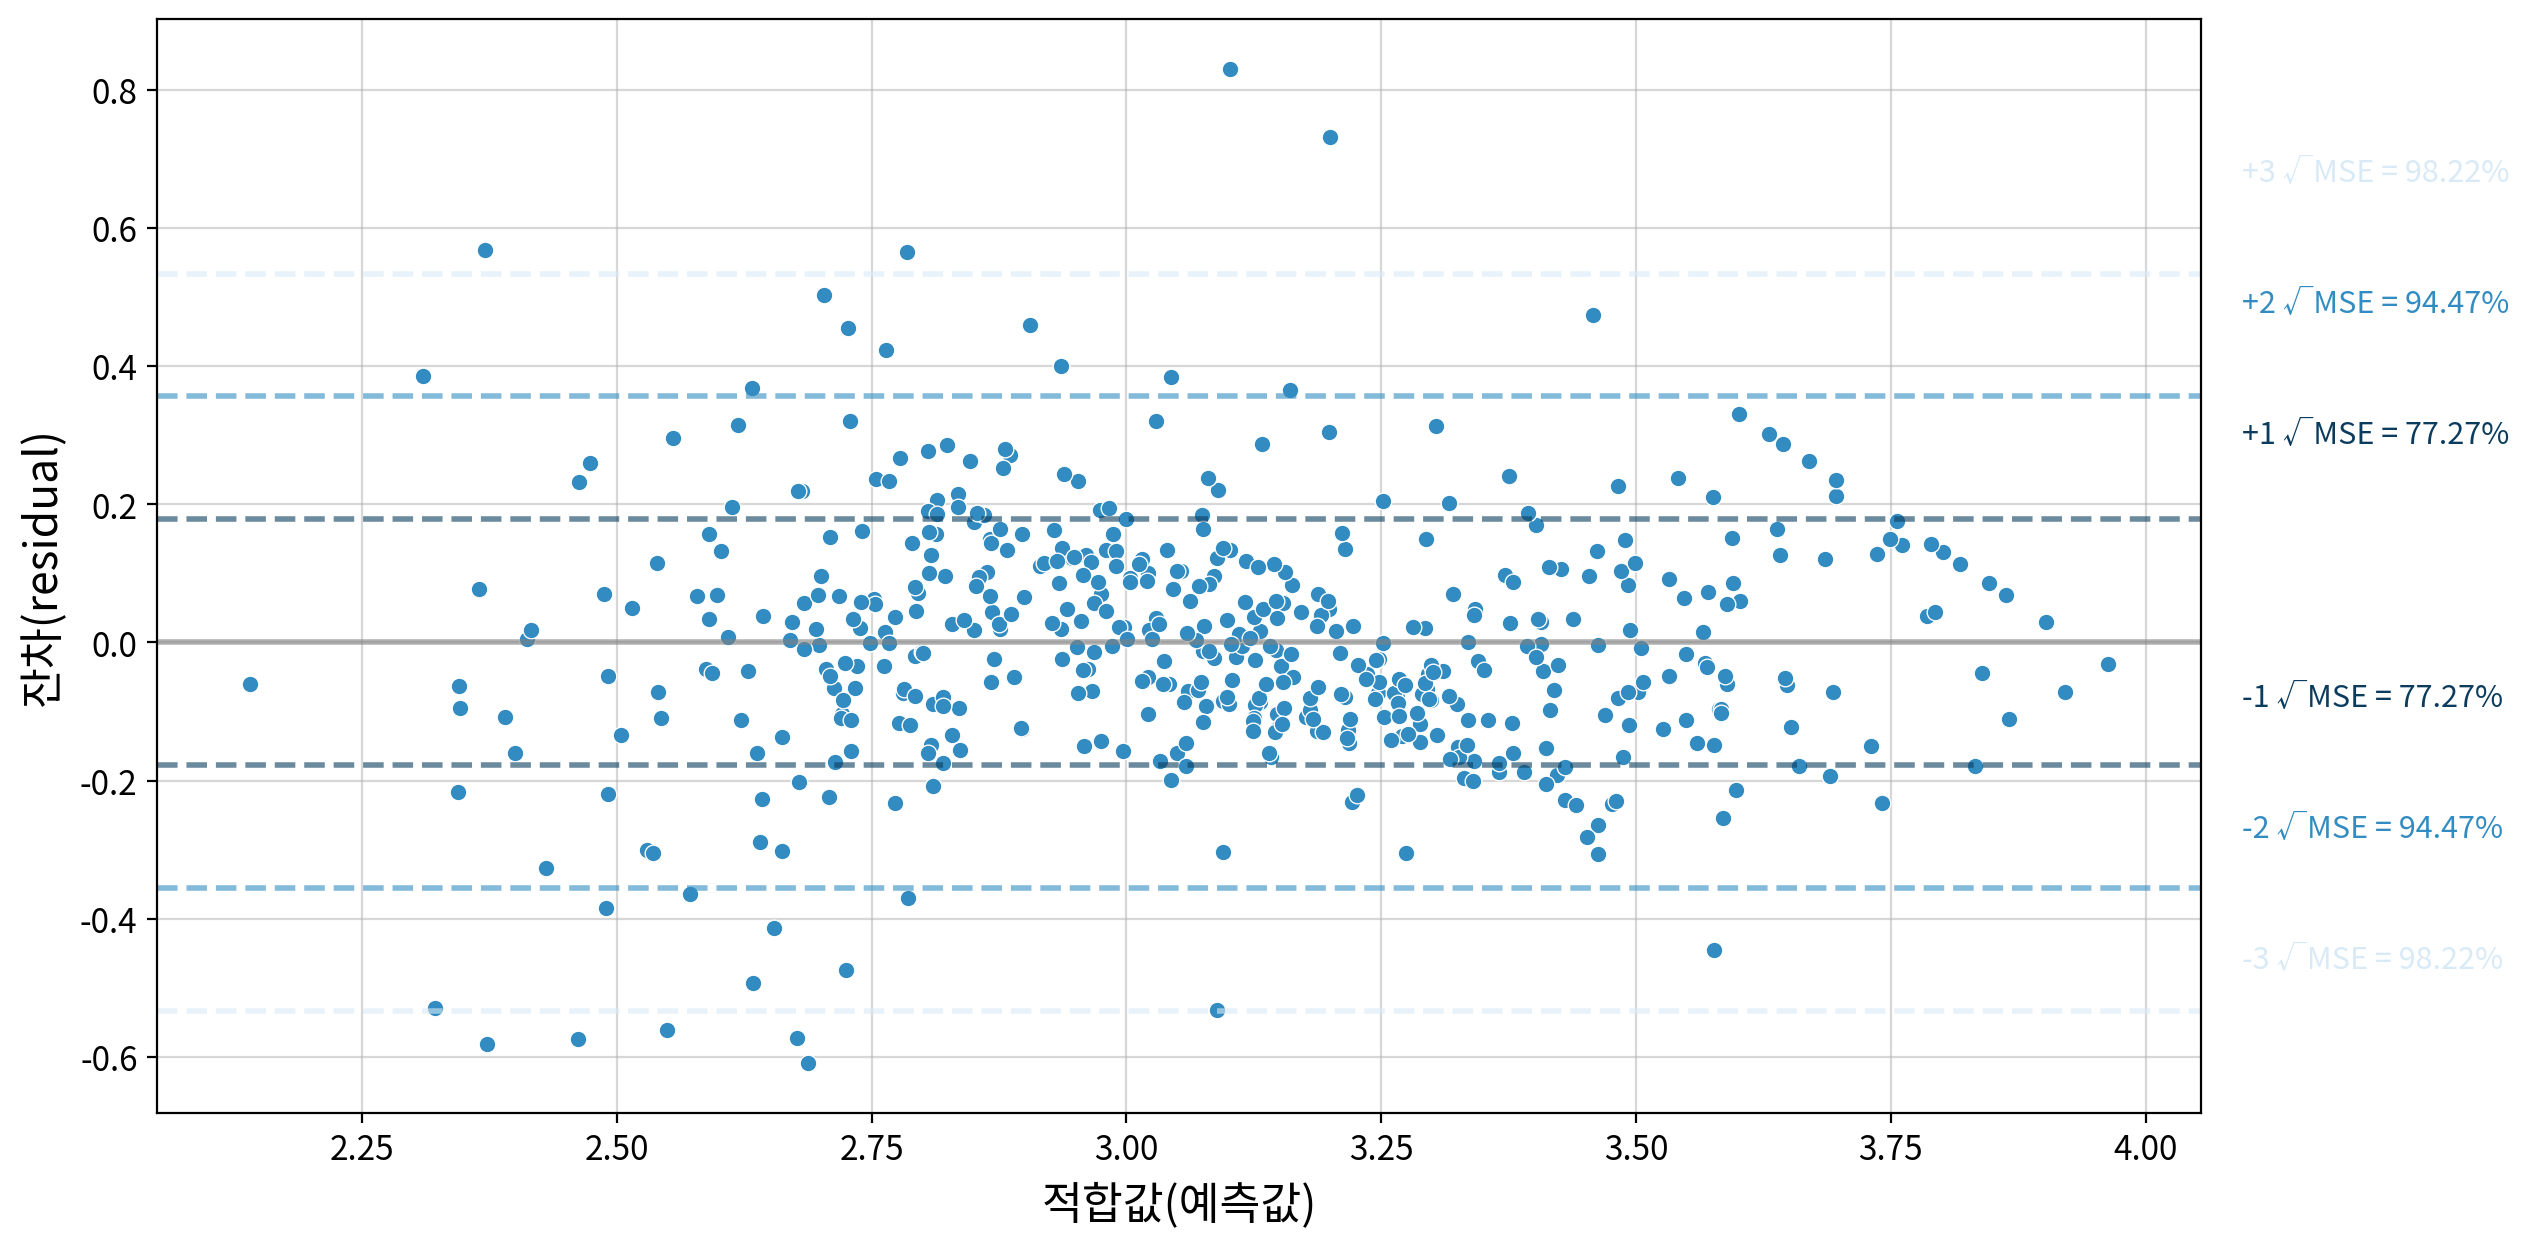

In [38]:
my_ols.test_normal(final_fit, plot=True)

### 3. 등분산성 검정

In [39]:
my_ols.test_equalvar(final_fit)

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,77.414,0.000,9.954,0.000,False,대립가설 채택 → 등분산 아님


### 4. 독립성 검정

In [40]:
my_ols.test_independent(final_fit)

,statistic,independence,result
Durbin-Watso,1.037,False,독립성 위반 (양(+)의 자기상관)


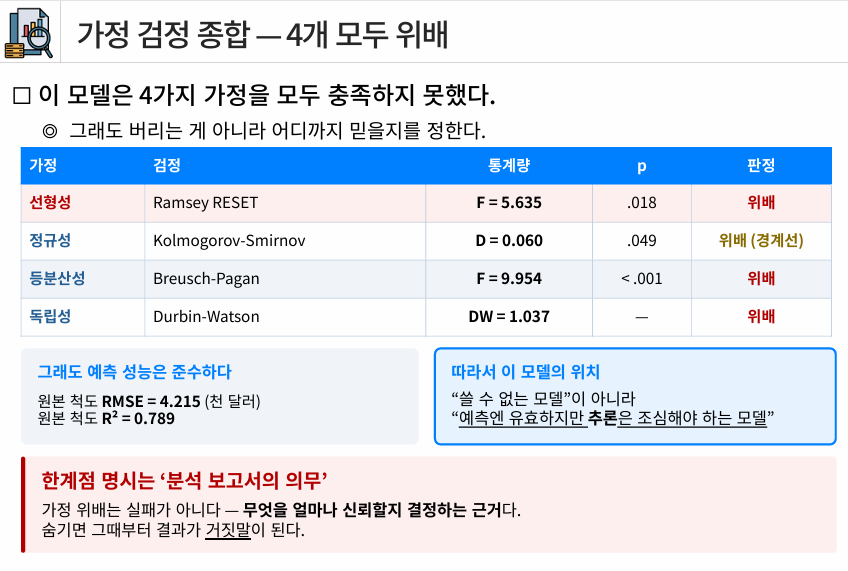

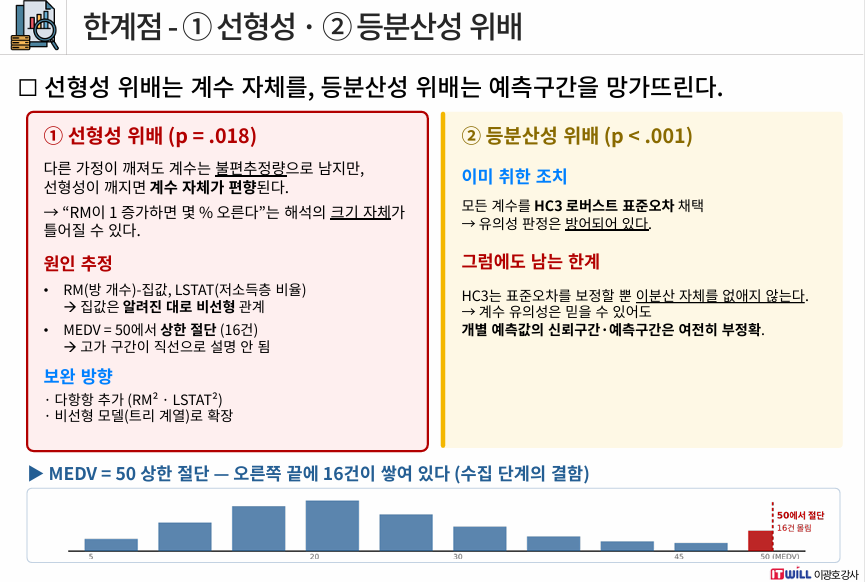

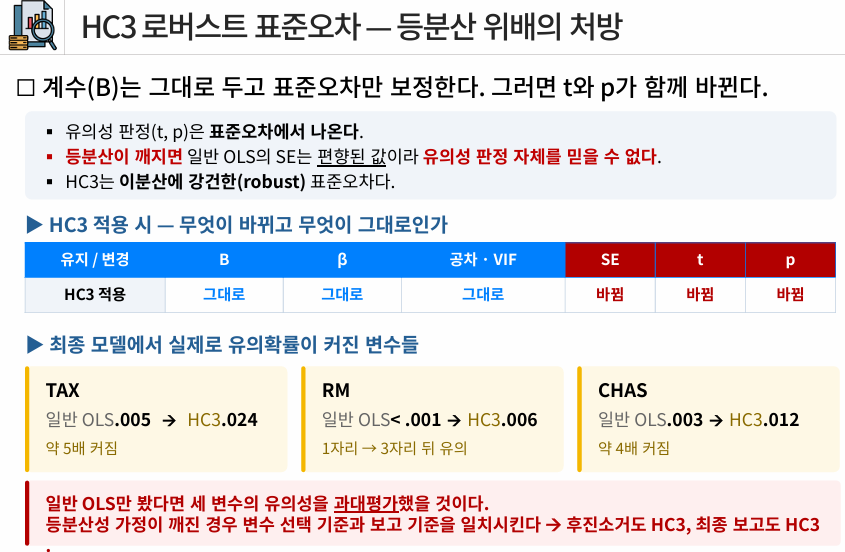

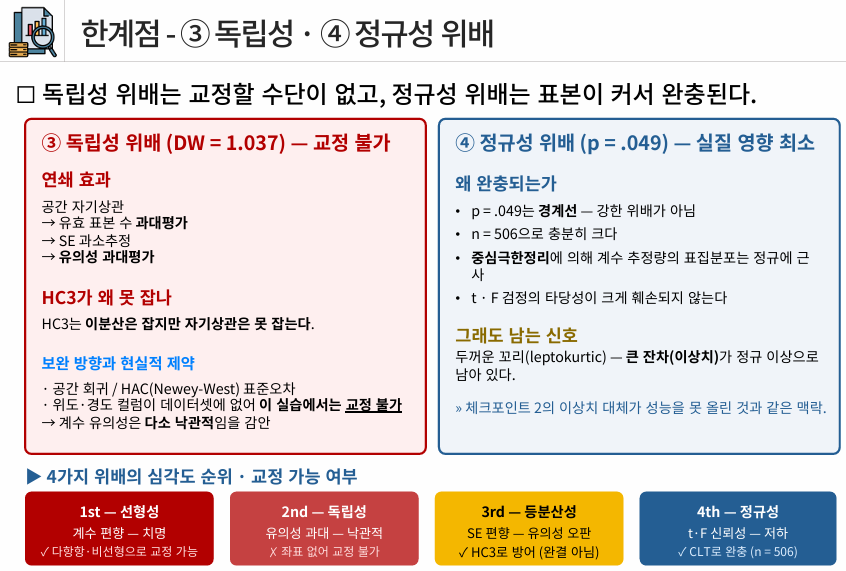

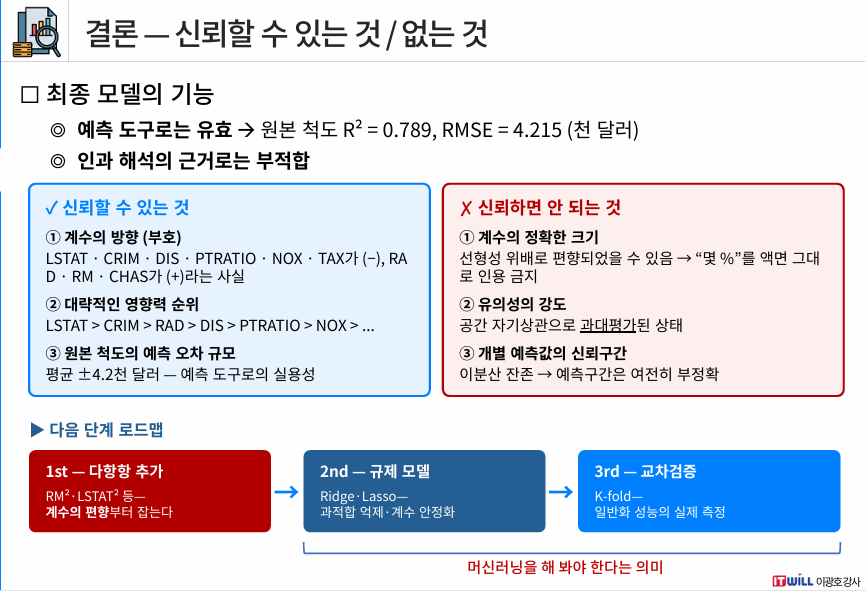